In [2]:
import numpy as np
import pandas as pd 
pd.set_option('display.max_columns',None)
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [3]:
# imprtration du dataset
pd.set_option('display.max_rows', None)
df = pd.read_csv('Data_Driven_Healthcare.csv', sep=';', encoding='utf-8', on_bad_lines='skip')
df.head(2)

,Name,Age,Age check,Updated Age,Age Group,Gender,Trimmed Gender,Updated Gender,Demographic Group,Blood Type,Updated Blood Type,Medical Condition,Updated Medical Condition,Date of Admission,Date Check,Day,Month,Year,Updated Date of Admission,Day of admission,Month of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Billing Check,Billing Amount - Number,Updated Billing Amount,Room Number,Admission Type,Trimmed Ad Type,Updated Admission Type,Discharge Date,Day.1,Month.1,Year.1,Updated Discharge Date,Medication,Test Results,Days of admission
0,Tiffany Ramirez,81,VRAI,81,c. Senior Citizens,Female,Female,Female,c. Senior Citizens - Female,O-,O-,Diabetes,Diabetes,44882,44882,17,11,2022,17/11/2022,17/01/1900,2022-11,Patrick Parker,Wallace-Hamilton,Medicare,"44989,18004",VRAI,"44989,18004","44989,18004",146,Elective,Elective,Elective,44889,24,11,2022,24/11/2022,Aspirin,Inconclusive,7
1,Ruben Burns,35,VRAI,35,b. Middle Aged,Male,Male,Male,b. Middle Aged - Male,O+,O+,Asthma,Asthma,45087,45087,10,6,2023,10/06/2023,10/01/1900,2023-06,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,"42573,65836",VRAI,"42573,65836","42573,65836",404,Emer,Emer,Emergency,45101,24,6,2023,24/06/2023,Lipitor,Normal,14


In [4]:
# suppressions des colonnes Year.1,Month.1,	Day.1,Day,Month,Year,Updated Medical Condition,Updated Blood Type,Updated Gender,Trimmed Gender,Updated Age
drop_colums = ['Year.1','Month.1','Day.1','Day','Month','Year','Updated Medical Condition','Updated Blood Type','Updated Gender','Updated Age','Date of Admission','Date Check','Day of admission','Month of Admission','Billing Amount - Number','Updated Billing Amount','Discharge Date']
data = df.drop(drop_colums,axis=1)


In [5]:
data.head(2)

,Name,Age,Age check,Age Group,Gender,Trimmed Gender,Demographic Group,Blood Type,Medical Condition,Updated Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Billing Check,Room Number,Admission Type,Trimmed Ad Type,Updated Admission Type,Updated Discharge Date,Medication,Test Results,Days of admission
0,Tiffany Ramirez,81,VRAI,c. Senior Citizens,Female,Female,c. Senior Citizens - Female,O-,Diabetes,17/11/2022,Patrick Parker,Wallace-Hamilton,Medicare,"44989,18004",VRAI,146,Elective,Elective,Elective,24/11/2022,Aspirin,Inconclusive,7
1,Ruben Burns,35,VRAI,b. Middle Aged,Male,Male,b. Middle Aged - Male,O+,Asthma,10/06/2023,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,"42573,65836",VRAI,404,Emer,Emer,Emergency,24/06/2023,Lipitor,Normal,14


<style>
    body {
        background-color: #001427; /* bleu nuit */
        margin: 0;
        padding: 10px;
        font-family: Arial, Helvetica, sans-serif;
    }
    .metadata-table {
        width: 100%;
        border-collapse: collapse;
        margin: 20px 0;
        box-shadow: 0 2px 6px rgba(0,0,0,0.4);
        background: rgba(0,0,0,0.15);
    }
    .metadata-table th {
        background-color: #040320; /* encre / bleu foncé */
        color: #2bff00;           /* jaune or */
        padding: 12px;
        text-align: left;
        font-weight: 700;
        border-bottom: 2px solid rgba(255,215,0,0.15);
    }
    .metadata-table td {
        padding: 10px 12px;
        border-bottom: 1px solid rgba(255,255,255,0.04);
        color: rgb(0, 255, 136);           /* vert citron */
        vertical-align: top;
    }
    .metadata-table tr:hover td {
        background-color: rgba(191,255,0,0.03);
    }
    .metadata-table tr:nth-child(even) td {
        background-color: rgba(255,255,255,0.01);
    }
    .column-name {
        font-weight: 700;
        color: rgb(255, 215, 0); /* jaune or */
        width: 22%;
    }
    .column-desc {
        color: #bfff00; /* vert citron */
    }
</style>

<table class="metadata-table">
    <thead>
        <tr>
            <th>Colonne</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td class="column-name">Name</td>
            <td class="column-desc">Nom du patient</td>
        </tr>
        <tr>
            <td class="column-name">Age</td>
            <td class="column-desc">L'age du patient</td>
        </tr>
        <tr>
            <td class="column-name">Age Group</td>
            <td class="column-desc">Groupe age auquel appartient le patient</td>
        </tr>
        <tr>
            <td class="column-name">Gender</td>
            <td class="column-desc">Sexe du patient</td>
        </tr>
        <tr>
            <td class="column-name">Demographic Group</td>
            <td class="column-desc">Sert à regrouper les patients selon des caracteristiques socio-démographiques</td>
        </tr>
        <tr>
            <td class="column-name">Blood Type</td>
            <td class="column-desc">Indique le group sanguin du patient</td>
        </tr>
        <tr>
            <td class="column-name">Medical Condition</td>
            <td class="column-desc">Indique la pathologie principale du patient</td>
        </tr>
        <tr>
            <td class="column-name">Updated Date of Admission</td>
            <td class="column-desc">Indique le jour où le traitement, le médicament ou une procédure médicale a été administrée au patient</td>
        </tr>
        <tr>
            <td class="column-name">Insurance Provider</td>
            <td class="column-desc">Indique la compagnie d'assurance santé couvrant le patient</td>
        </tr>
        <tr>
            <td class="column-name">Billing Amount</td>
            <td class="column-desc">Montant facturé pour les soins ou services médicaux reçus par un patient</td>
        </tr>
        <tr>
            <td class="column-name">Room Number</td>
            <td class="column-desc">Numéro de chambre attribué lors de l'hospitalisation</td>
        </tr>
        <tr>
            <td class="column-name">Updated Discharge Date</td>
            <td class="column-desc">Date de sortie du patient de l'hôpital</td>
        </tr>
        <tr>
            <td class="column-name">Medication</td>
            <td class="column-desc">Médicament administré pendant l'hospitalisation</td>
        </tr>
        <tr>
            <td class="column-name">Test Results</td>
            <td class="column-desc">Résultats médicaux obtenus lors des analyses cliniques</td>
        </tr>
        <tr>
            <td class="column-name">Days of admission</td>
            <td class="column-desc">Durée d'hospitalisation d'un patient</td>
        </tr>
        <tr>
            <td class="column-name">Admission Type</td>
            <td class="column-desc">Type d'admission (urgence, planifiée, etc.)</td>
        </tr>
    </tbody>
</table>

In [6]:
# informations sur les données
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Name                       10000 non-null  object
 1   Age                        10000 non-null  object
 2   Age check                  10000 non-null  object
 3   Age Group                  10000 non-null  object
 4   Gender                     10000 non-null  object
 5   Trimmed Gender             10000 non-null  object
 6   Demographic Group          10000 non-null  object
 7   Blood Type                 10000 non-null  object
 8   Medical Condition          10000 non-null  object
 9   Updated Date of Admission  10000 non-null  object
 10  Doctor                     10000 non-null  object
 11  Hospital                   10000 non-null  object
 12  Insurance Provider         10000 non-null  object
 13   Billing Amount            9976 non-null   object
 14  Billing

In [7]:
data.isnull().sum()

Name                          0
Age                           0
Age check                     0
Age Group                     0
Gender                        0
Trimmed Gender                0
Demographic Group             0
Blood Type                    0
Medical Condition             0
Updated Date of Admission     0
Doctor                        0
Hospital                      0
Insurance Provider            0
 Billing Amount              24
Billing Check                 0
Room Number                   0
Admission Type                0
Trimmed Ad Type               0
Updated Admission Type        0
Updated Discharge Date        0
Medication                    0
Test Results                  0
Days of admission             0
dtype: int64

In [8]:
# affichage du dataset
data.head(2)

,Name,Age,Age check,Age Group,Gender,Trimmed Gender,Demographic Group,Blood Type,Medical Condition,Updated Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Billing Check,Room Number,Admission Type,Trimmed Ad Type,Updated Admission Type,Updated Discharge Date,Medication,Test Results,Days of admission
0,Tiffany Ramirez,81,VRAI,c. Senior Citizens,Female,Female,c. Senior Citizens - Female,O-,Diabetes,17/11/2022,Patrick Parker,Wallace-Hamilton,Medicare,"44989,18004",VRAI,146,Elective,Elective,Elective,24/11/2022,Aspirin,Inconclusive,7
1,Ruben Burns,35,VRAI,b. Middle Aged,Male,Male,b. Middle Aged - Male,O+,Asthma,10/06/2023,Diane Jackson,"Burke, Griffin and Cooper",UnitedHealthcare,"42573,65836",VRAI,404,Emer,Emer,Emergency,24/06/2023,Lipitor,Normal,14


In [9]:
data['Updated Discharge Date'] = pd.to_datetime(data['Updated Discharge Date'], format='%d/%m/%Y')
data['Updated Date of Admission'] = pd.to_datetime(data['Updated Date of Admission'], format='%d/%m/%Y')



In [10]:
data.columns = data.columns.str.strip()
'Billing Amount' in data.columns

True

In [11]:
# 
data.columns = data.columns.str.strip().str.replace('\xa0',' ').str.replace('\n',' ') 
print(data.columns.tolist())

['Name', 'Age', 'Age check', 'Age Group', 'Gender', 'Trimmed Gender', 'Demographic Group', 'Blood Type', 'Medical Condition', 'Updated Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Billing Check', 'Room Number', 'Admission Type', 'Trimmed Ad Type', 'Updated Admission Type', 'Updated Discharge Date', 'Medication', 'Test Results', 'Days of admission']


In [12]:
# comptage des valeurs manquantes
data.isna().sum()

Name                          0
Age                           0
Age check                     0
Age Group                     0
Gender                        0
Trimmed Gender                0
Demographic Group             0
Blood Type                    0
Medical Condition             0
Updated Date of Admission     0
Doctor                        0
Hospital                      0
Insurance Provider            0
Billing Amount               24
Billing Check                 0
Room Number                   0
Admission Type                0
Trimmed Ad Type               0
Updated Admission Type        0
Updated Discharge Date        0
Medication                    0
Test Results                  0
Days of admission             0
dtype: int64

In [13]:
# affichage des 5 premières valeurs de la colonne 'Billing Amount' avec leur représentation littérale
print(data['Billing Amount'].head().apply(lambda x: repr(x)))

0    '44989,18004'
1    '42573,65836'
2     '18437,4485'
3    '20972,98988'
4    '14469,07535'
Name: Billing Amount, dtype: object


## Feature Engineering

In [14]:
#  entier en decimal
data['Billing Amount'] = data['Billing Amount'].apply(lambda x: float(x) if isinstance(x,int) else x)

In [15]:
# conversion de la colonne 'Billing Amount' en float
data['Billing Amount'] =(
    data['Billing Amount']
    .astype(str)        # assure que tout est en string
    .str.replace(',', '.', regex= False) # remplace virgule par point
    .str.strip()             # supprime les espaces
)

In [16]:
# conversion en float  avec gestion des erreurs
data['Billing Amount'] = pd.to_numeric(data['Billing Amount'],errors='coerce')

In [17]:
data['Billing Amount'] =data['Billing Amount'].fillna(4523.33255)

In [18]:
data['Age'] = data['Age'].str.replace('8I','81')

In [19]:
data['Age'] =(
    data['Age']
    .astype(str)        # assure que tout est en string
    # .str.replace(',', '.', regex= False) # remplace virgule par point
    .str.strip()             # supprime les espaces
)

In [20]:
data['Age'] = pd.to_numeric(data['Age'])

In [21]:
data['Age'] = data['Age'].astype(int)

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Name                       10000 non-null  object        
 1   Age                        10000 non-null  int64         
 2   Age check                  10000 non-null  object        
 3   Age Group                  10000 non-null  object        
 4   Gender                     10000 non-null  object        
 5   Trimmed Gender             10000 non-null  object        
 6   Demographic Group          10000 non-null  object        
 7   Blood Type                 10000 non-null  object        
 8   Medical Condition          10000 non-null  object        
 9   Updated Date of Admission  10000 non-null  datetime64[ns]
 10  Doctor                     10000 non-null  object        
 11  Hospital                   10000 non-null  object        
 12  Insur

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Name                       10000 non-null  object        
 1   Age                        10000 non-null  int64         
 2   Age check                  10000 non-null  object        
 3   Age Group                  10000 non-null  object        
 4   Gender                     10000 non-null  object        
 5   Trimmed Gender             10000 non-null  object        
 6   Demographic Group          10000 non-null  object        
 7   Blood Type                 10000 non-null  object        
 8   Medical Condition          10000 non-null  object        
 9   Updated Date of Admission  10000 non-null  datetime64[ns]
 10  Doctor                     10000 non-null  object        
 11  Hospital                   10000 non-null  object        
 12  Insur

In [24]:
data.isnull().sum()

Name                         0
Age                          0
Age check                    0
Age Group                    0
Gender                       0
Trimmed Gender               0
Demographic Group            0
Blood Type                   0
Medical Condition            0
Updated Date of Admission    0
Doctor                       0
Hospital                     0
Insurance Provider           0
Billing Amount               0
Billing Check                0
Room Number                  0
Admission Type               0
Trimmed Ad Type              0
Updated Admission Type       0
Updated Discharge Date       0
Medication                   0
Test Results                 0
Days of admission            0
dtype: int64

In [25]:
# affichage des valeurs uniques de la colonne 'Gender'
data['Gender'].unique()

array(['Female', 'Male', 'M '], dtype=object)

In [26]:
# comptage des valeurs de la colonne
Gender = data['Gender'].value_counts().reset_index()
Gender

,Gender,count
0,Female,5075
1,Male,4805
2,M,120


In [27]:
# remplacement des valeurs 'M' par 'Male' dans la colonne 'Gender'  
data['Gender'] = data['Gender'].str.replace('M','Male')

In [28]:
# comptage des occurrences de chaque genre
Gender = data['Gender'].value_counts().reset_index()
Gender

,Gender,count
0,Female,5075
1,Maleale,4805
2,Male,120


In [29]:
# remplacement des valeurs 'Maleale' par 'Male' dans la colonne 'Gender'
data['Gender'] = data['Gender'].str.replace('Maleale','Male')

In [30]:
# comptage des occurrences de chaque genre  
Gender = data['Gender'].value_counts().reset_index()
Gender

,Gender,count
0,Female,5075
1,Male,4805
2,Male,120


In [31]:
# pour suprimer les expaces dans la colonne Gender
data['Gender'] = data['Gender'].str.strip().str.replace(' ','')

In [32]:
#  pour supprimer 'Male' qui est un doublon dans la colonne Gender
data['Gender'] = data['Gender'].apply(lambda x: 'Male' if x== 'Male,Male' else x)

In [33]:
Gender = data['Gender'].value_counts().reset_index()
Gender

,Gender,count
0,Female,5075
1,Male,4925


<function matplotlib.pyplot.show(close=None, block=None)>

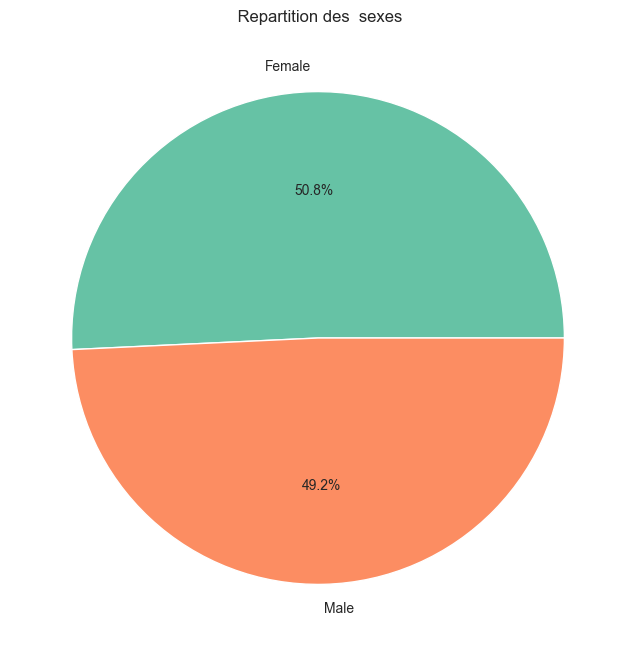

In [34]:
Gender.columns = ['Gender','count']
plt.figure(figsize=(8,8))
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.pie(Gender['count'],labels= Gender['Gender'],autopct='%1.1f%%')
plt.title(' Repartition des  sexes')
plt.show


In [35]:
# comptage des valeurs de la colonne 'Age Group'
groupAge = data['Age Group'].value_counts().reset_index()
groupAge

,Age Group,count
0,b. Middle Aged,3854
1,c. Senior Citizens,3661
2,a. Young Adults,2485


<function matplotlib.pyplot.show(close=None, block=None)>

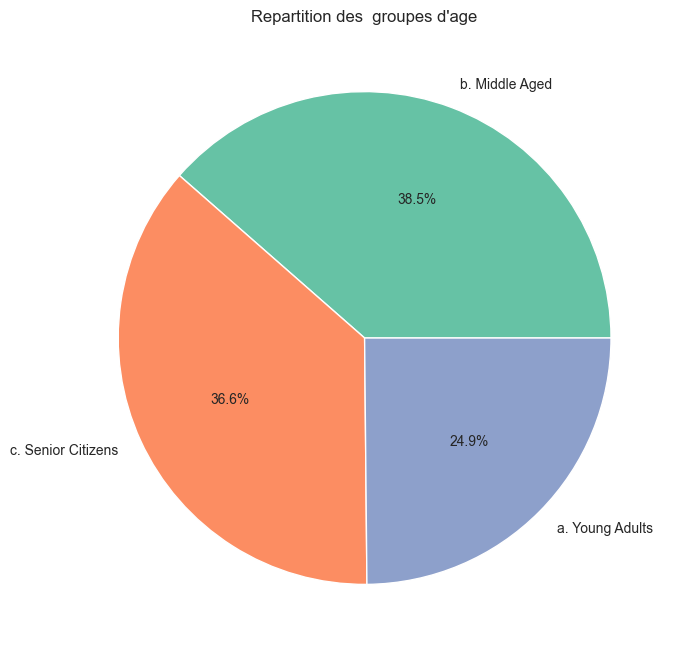

In [36]:
groupAge.columns = ['Age Group','count']
plt.figure(figsize=(8,8))
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.pie(groupAge['count'],labels= groupAge['Age Group'],autopct='%1.1f%%')
plt.title("Repartition des  groupes d'age")
plt.show

In [37]:
# 
demographic = data['Demographic Group'].value_counts().reset_index().sort_values(by='count',ascending=True)
demographic

,Demographic Group,count
5,a. Young Adults - Male,1235
4,a. Young Adults - Female,1250
3,c. Senior Citizens - Male,1780
2,c. Senior Citizens - Female,1881
1,b. Middle Aged - Male,1910
0,b. Middle Aged - Female,1944


C:\Users\user\AppData\Local\Temp\ipykernel_4432\4081496641.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(x='Demographic Group',y='count', data= demographic,palette='hsv')


<function matplotlib.pyplot.show(close=None, block=None)>

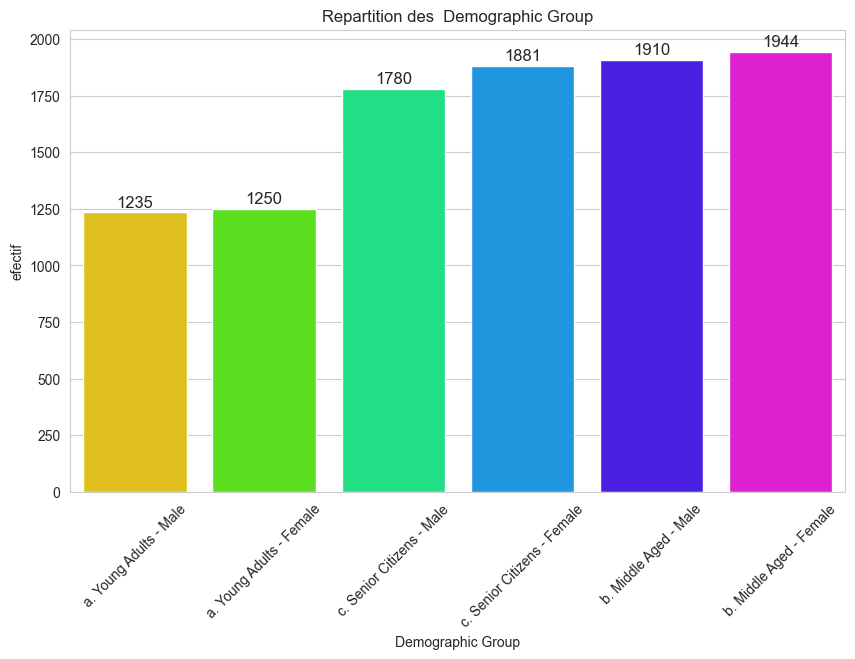

In [38]:
demographic.columns = ['Demographic Group','count']
plt.figure(figsize=(10,6))
ax =sns.barplot(x='Demographic Group',y='count', data= demographic,palette='hsv')
plt.title("Repartition des  Demographic Group")
plt.xlabel('Demographic Group')
plt.ylabel('efectif')
plt.tick_params(axis='x',rotation=45)

for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 12)
plt.show

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Name                       10000 non-null  object        
 1   Age                        10000 non-null  int64         
 2   Age check                  10000 non-null  object        
 3   Age Group                  10000 non-null  object        
 4   Gender                     10000 non-null  object        
 5   Trimmed Gender             10000 non-null  object        
 6   Demographic Group          10000 non-null  object        
 7   Blood Type                 10000 non-null  object        
 8   Medical Condition          10000 non-null  object        
 9   Updated Date of Admission  10000 non-null  datetime64[ns]
 10  Doctor                     10000 non-null  object        
 11  Hospital                   10000 non-null  object        
 12  Insur

In [40]:
# comptage des valeurs de la colonne 'Blood Type'
bloodtype = data['Blood Type'].value_counts().reset_index().sort_values(by='count',ascending=True)
bloodtype

,Blood Type,count
13,0+,1
12,AB negative,22
11,O neg,27
9,A+ve,35
10,O+ve,35
8,B+ve,41
7,B+,1203
6,A+,1206
5,O+,1212
4,O-,1217


#### La colonne **Blood Type** doit etre nettoyer

In [41]:
# pour suprimer les expaces dans la colonne 
#  Avant d nettoyer une colone il faut d'abord penser à nettiyer les expacces unitiles pour faciliter le nettoyage
data['Blood Type'] = data['Blood Type'].str.strip().str.replace(' ','')

In [42]:
data['Blood Type'] =data['Blood Type'].str.replace('AB negative','AB-')
data['Blood Type'] =data['Blood Type'].str.replace('ABnegative','AB-')
data['Blood Type'] =data['Blood Type'].str.replace('ABnegative','AB-')
data['Blood Type'] =data['Blood Type'].str.replace('Oneg','O-')
data['Blood Type'] =data['Blood Type'].str.replace('0+','O+')
data['Blood Type'] =data['Blood Type'].str.replace('O+ve','O+')
data['Blood Type'] =data['Blood Type'].str.replace('A+ve','A+')
data['Blood Type'] =data['Blood Type'].str.replace('B+ve','B+')

In [43]:
data['Blood Type'].value_counts()

Blood Type
AB-    1275
AB+    1258
B-     1252
O+     1248
O-     1244
B+     1244
A+     1241
A-     1238
Name: count, dtype: int64

In [44]:
# comptage des valeurs de la colonne 'Blood Type'
bloodtype = data['Blood Type'].value_counts().reset_index().sort_values(by='count',ascending=True)
bloodtype

,Blood Type,count
7,A-,1238
6,A+,1241
4,O-,1244
5,B+,1244
3,O+,1248
2,B-,1252
1,AB+,1258
0,AB-,1275


C:\Users\user\AppData\Local\Temp\ipykernel_4432\1809788669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Blood Type',y='count', data= bloodtype,palette='Set1')


<function matplotlib.pyplot.show(close=None, block=None)>

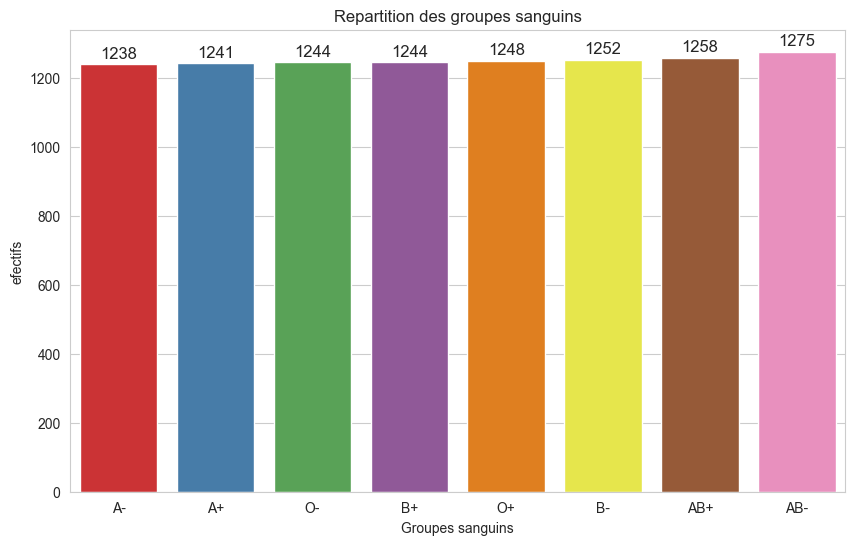

In [45]:
bloodtype.columns = ['Blood Type','count']
plt.figure(figsize=(10,6))
ax = sns.barplot(x='Blood Type',y='count', data= bloodtype,palette='Set1')
plt.title("Repartition des groupes sanguins")
plt.xlabel('Groupes sanguins')
plt.ylabel('efectifs')

for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 12)
plt.show

In [46]:
# comptage des valeurs de la colonne 'Medical Condition'
medical = data['Medical Condition'].value_counts().reset_index().sort_values(by='count',ascending=True)
medical

,Medical Condition,count
5,Diabetes,1434
4,Asthma,1550
3,ARTHRITIS,1587
2,Obesity,1627
1,Cancer,1647
0,hypertension,2155


<function matplotlib.pyplot.show(close=None, block=None)>

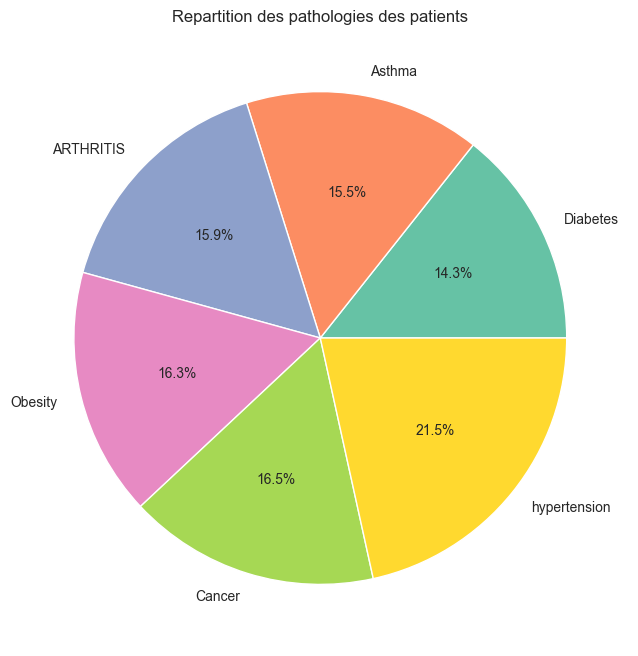

In [47]:
medical.columns = ['Medical Condition','count']
plt.figure(figsize=(8,8))
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.pie(medical['count'],labels= medical['Medical Condition'],autopct='%1.1f%%')
plt.title("Repartition des pathologies des patients")
plt.show

In [48]:
# comptage des valeurs de la colonne 'Insurance Provider'
insurance = data['Insurance Provider'].value_counts().reset_index().sort_values(by='count',ascending=True)
insurance

,Insurance Provider,count
4,UnitedHealthcare,1837
3,Blue Cross,1875
2,Aetna,1921
1,Cigna,1939
0,Medicare,2428


C:\Users\user\AppData\Local\Temp\ipykernel_4432\3873943805.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Insurance Provider',y='count', data= insurance,palette='Set1')


<function matplotlib.pyplot.show(close=None, block=None)>

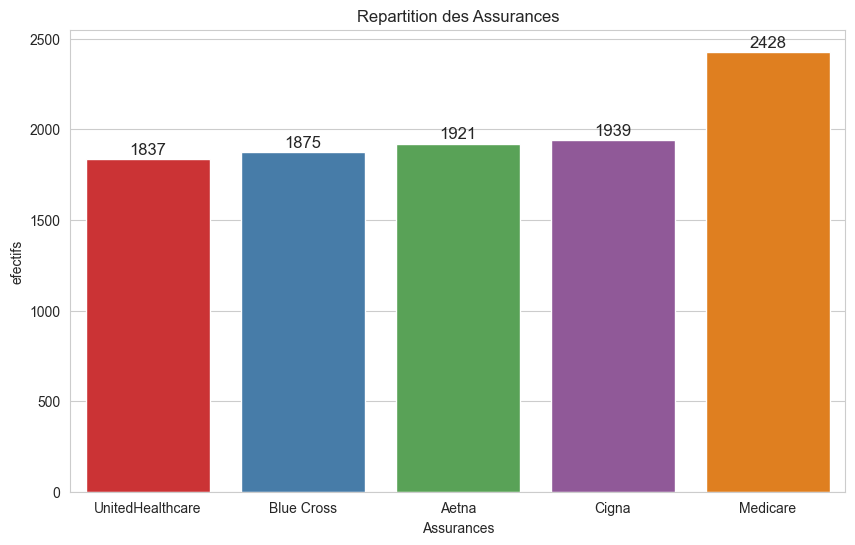

In [49]:
insurance.columns = ['Insurance Provider','count']
plt.figure(figsize=(10,6))
ax=sns.barplot(x='Insurance Provider',y='count', data= insurance,palette='Set1')
plt.title("Repartition des Assurances")
plt.xlabel('Assurances')
plt.ylabel('efectifs')
# plt.tick_params(axis='x',rotation=45)

for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 12)
plt.show

In [50]:
data.columns.tolist()

['Name',
 'Age',
 'Age check',
 'Age Group',
 'Gender',
 'Trimmed Gender',
 'Demographic Group',
 'Blood Type',
 'Medical Condition',
 'Updated Date of Admission',
 'Doctor',
 'Hospital',
 'Insurance Provider',
 'Billing Amount',
 'Billing Check',
 'Room Number',
 'Admission Type',
 'Trimmed Ad Type',
 'Updated Admission Type',
 'Updated Discharge Date',
 'Medication',
 'Test Results',
 'Days of admission']

In [51]:
data['Admission Type'].value_counts()

Admission Type
Emergency    3533
Urgent       3336
Elective     3077
Emer           54
Name: count, dtype: int64

In [52]:
# pour suprimer les expaces dans la colonne Gender
data['Admission Type'] = data['Admission Type'].str.strip().str.replace(' ','')


In [53]:
# remplacement des valeurs 'Emer' par 'Emergency' dans la colonne 'Admission Type'
data['Admission Type'] =data['Admission Type'].str.replace('Emer','Emergency')
data['Admission Type'] =data['Admission Type'].str.replace('Emergencygencygency','Emergency')
data['Admission Type'] =data['Admission Type'].str.replace('Emergencygency','Emergency')

In [54]:
# comptage des valeurs de la colonne 'Admission Type'
admissionType = data['Admission Type'].value_counts().reset_index().sort_values(by='count',ascending=True)
admissionType

,Admission Type,count
2,Elective,3077
1,Urgent,3336
0,Emergency,3587


C:\Users\user\AppData\Local\Temp\ipykernel_4432\4119342221.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Admission Type',y='count', data= admissionType,palette='Set1')


<function matplotlib.pyplot.show(close=None, block=None)>

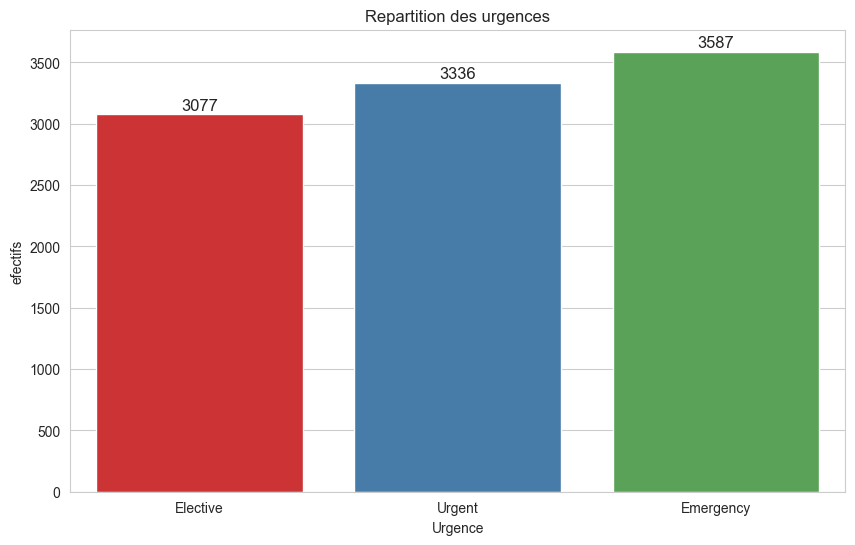

In [55]:
admissionType.columns = ['Admission Type','count']
plt.figure(figsize=(10,6))
ax=sns.barplot(x='Admission Type',y='count', data= admissionType,palette='Set1')
plt.title("Repartition des urgences")
plt.xlabel('Urgence')
plt.ylabel('efectifs')
# plt.tick_params(axis='x',rotation=45)

for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 12)
plt.show

In [56]:
# comptage des valeurs de la colonne 'Medication'
Medication = data['Medication'].value_counts().reset_index().sort_values(by='count',ascending=True)
Medication

,Medication,count
4,Paracetamol,1962
3,Aspirin,1968
2,Ibuprofen,1976
1,Lipitor,2015
0,Penicillin,2079


C:\Users\user\AppData\Local\Temp\ipykernel_4432\898803346.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='Medication',y='count', data= Medication,palette='viridis')


<function matplotlib.pyplot.show(close=None, block=None)>

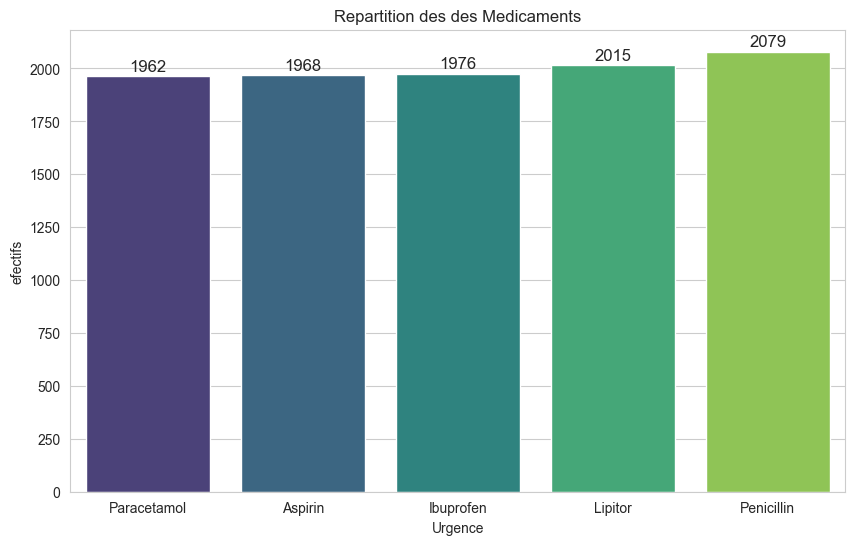

In [57]:
Medication.columns = ['Medication','count']
plt.figure(figsize=(10,6))
ax=sns.barplot(x='Medication',y='count', data= Medication,palette='viridis')
plt.title("Repartition des des Medicaments")
plt.xlabel('Urgence')
plt.ylabel('efectifs')
# plt.tick_params(axis='x',rotation=45)

for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 12)
plt.show

In [58]:
# comptage des valeurs de la colonne 'Test Results' 
test= data['Test Results'].value_counts().reset_index().sort_values(by='count',ascending=True)
test

,Test Results,count
2,Normal,3267
1,Inconclusive,3277
0,Abnormal,3456


<function matplotlib.pyplot.show(close=None, block=None)>

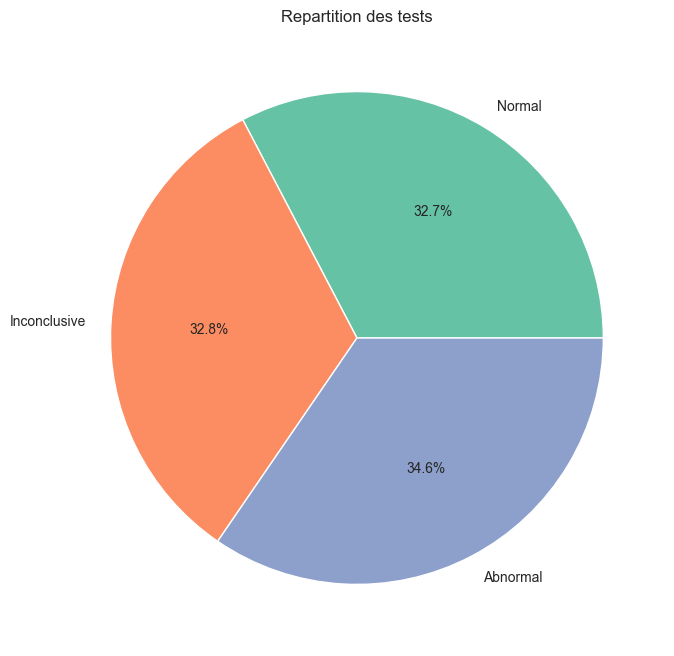

In [59]:
test.columns = ['Test Results','count']
plt.figure(figsize=(8,8))
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.pie(test['count'],labels= test['Test Results'],autopct='%1.1f%%')
plt.title("Repartition des tests")
plt.show

In [60]:
data.columns

Index(['Name', 'Age', 'Age check', 'Age Group', 'Gender', 'Trimmed Gender',
       'Demographic Group', 'Blood Type', 'Medical Condition',
       'Updated Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Billing Check', 'Room Number', 'Admission Type',
       'Trimmed Ad Type', 'Updated Admission Type', 'Updated Discharge Date',
       'Medication', 'Test Results', 'Days of admission'],
      dtype='object')

#### le tableaux de contingence entre la variable Demographic group et Medoical Condition

In [61]:
# création d'une table croisée entre 'Medical Condition' et 'Demographic Group'
MedCon_vs_DemGr = pd.crosstab(data['Medical Condition'],data['Demographic Group'])
MedCon_vs_DemGr

Demographic Group,a. Young Adults - Female,a. Young Adults - Male,b. Middle Aged - Female,b. Middle Aged - Male,c. Senior Citizens - Female,c. Senior Citizens - Male
Medical Condition,,,,,,
ARTHRITIS,132,135,317,275,372,356
Asthma,331,332,184,264,227,212
Cancer,153,164,374,271,309,376
Diabetes,204,132,298,272,323,205
Obesity,205,197,473,253,337,162
hypertension,225,275,298,575,313,469


<function matplotlib.pyplot.show(close=None, block=None)>

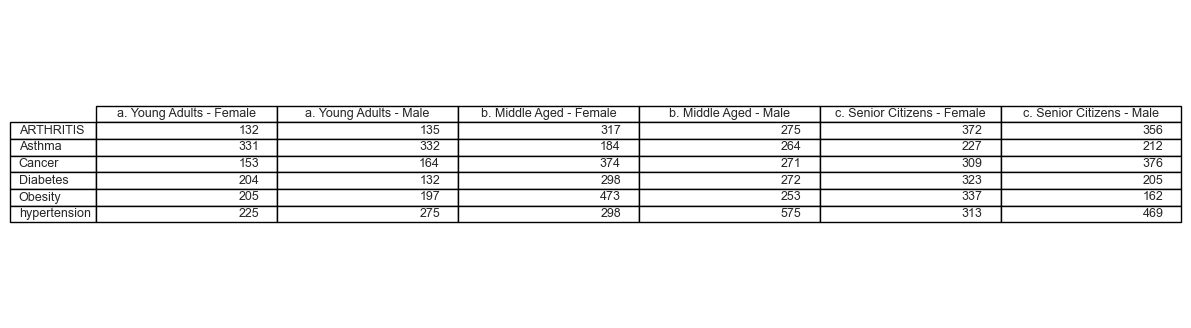

In [62]:
fig,ax = plt.subplots(figsize=(14,4))
ax.axis('off') # pour masquer les axes
ax.table(cellText=MedCon_vs_DemGr.values,rowLabels=MedCon_vs_DemGr.index,colLabels=MedCon_vs_DemGr.columns,loc='center')
plt.show

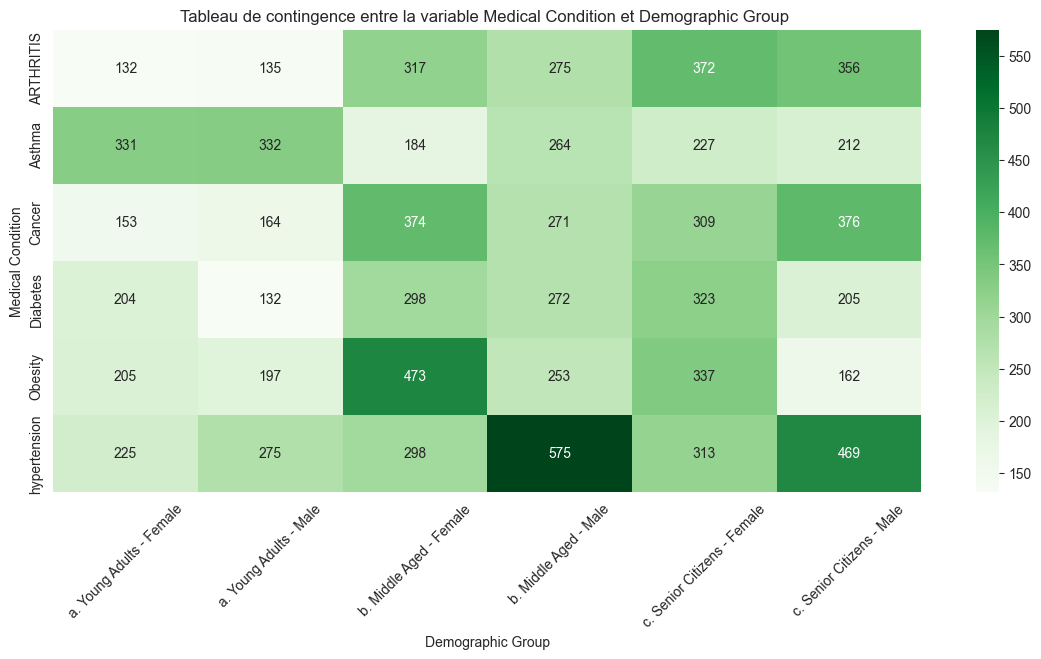

In [63]:
plt.figure(figsize=(14,6))
ax=sns.heatmap(MedCon_vs_DemGr,annot=True,cmap='Greens',fmt='d')
plt.title('Tableau de contingence entre la variable Medical Condition et Demographic Group ')
ax.set_xlabel('Demographic Group')
ax.set_ylabel('Medical Condition')
ax.tick_params(axis='x',rotation=45)
plt.show()

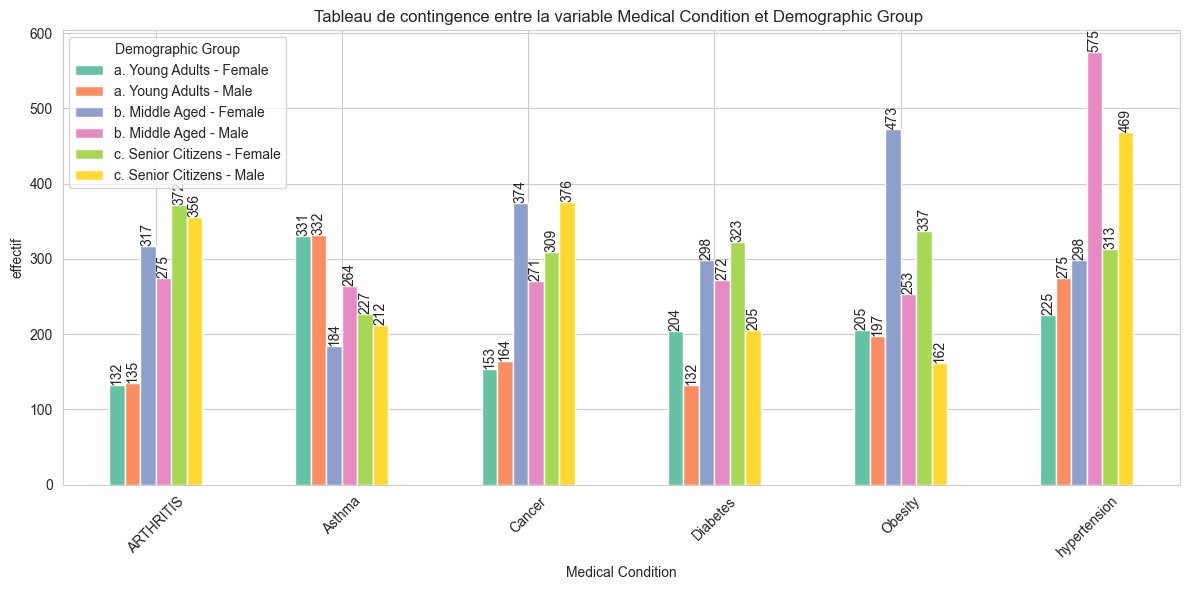

In [64]:
fig, ax= plt.subplots(figsize=(12,6))
MedCon_vs_DemGr.plot(kind ='bar',ax=ax)
ax.set_title('Tableau de contingence entre la variable Medical Condition et Demographic Group ')
ax.set_xlabel('Medical Condition')
ax.set_ylabel('effectif')
ax.tick_params(axis='x',rotation=45)
plt.tight_layout()

# pour ajouter les etiquettes verticales sur les barres
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),str(p.get_height()),ha='center',va='bottom',rotation=90)
plt.show()


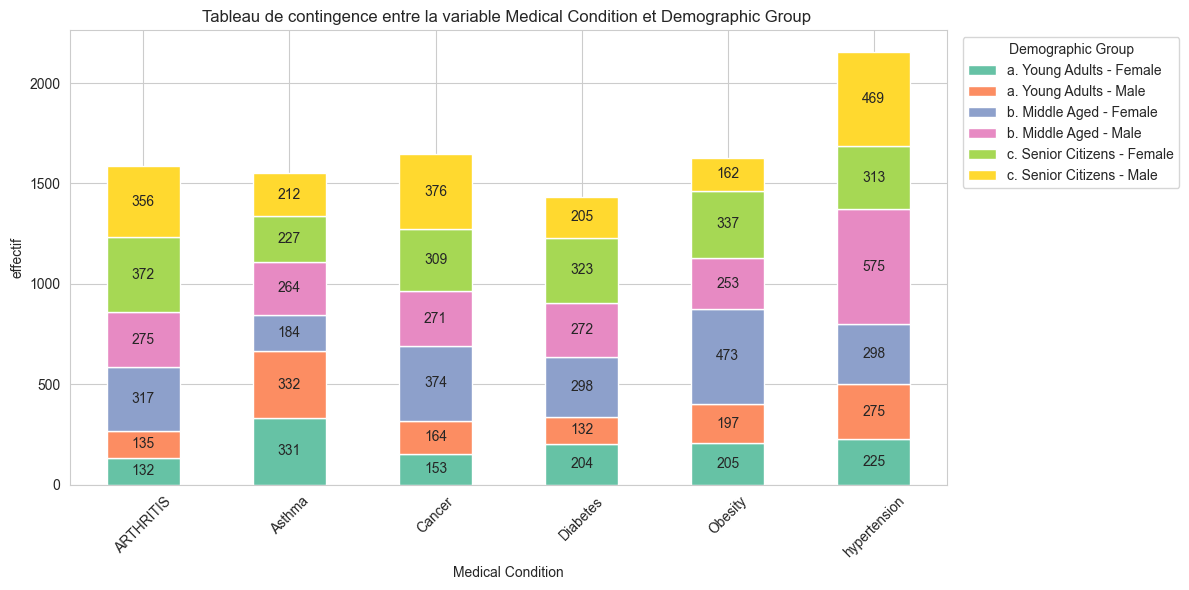

In [65]:
fig, ax = plt.subplots(figsize=(12,6))
MedCon_vs_DemGr.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Tableau de contingence entre la variable Medical Condition et Demographic Group ')
ax.set_xlabel('Medical Condition')
ax.set_ylabel('effectif')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Demographic Group', bbox_to_anchor=(1.01, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, label_type='center', fmt='%d')

plt.tight_layout()
plt.show()

In [66]:
# création d'une table croisée entre 'Medical Condition' et 'Gender'
MedCon_vs_Gender = pd.crosstab(data['Medical Condition'],data['Gender'])
MedCon_vs_Gender

Gender,Female,Male
Medical Condition,,
ARTHRITIS,821,766
Asthma,742,808
Cancer,836,811
Diabetes,825,609
Obesity,1015,612
hypertension,836,1319


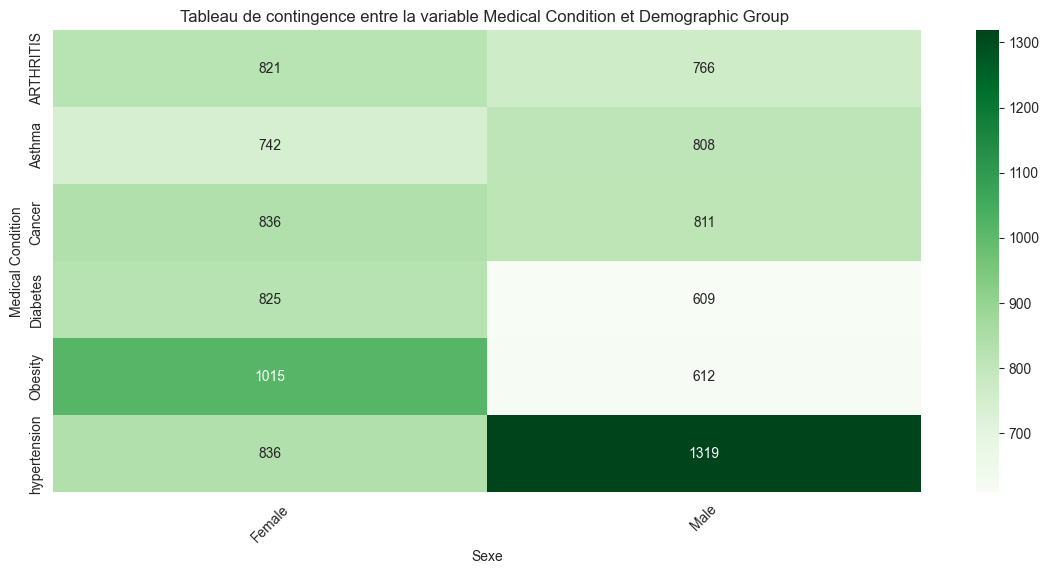

In [67]:
plt.figure(figsize=(14,6))
ax=sns.heatmap(MedCon_vs_Gender,annot=True,cmap='Greens',fmt='d')
plt.title('Tableau de contingence entre la variable Medical Condition et Demographic Group ')
ax.set_xlabel('Sexe')
ax.set_ylabel('Medical Condition')
ax.tick_params(axis='x',rotation=45)
plt.show()

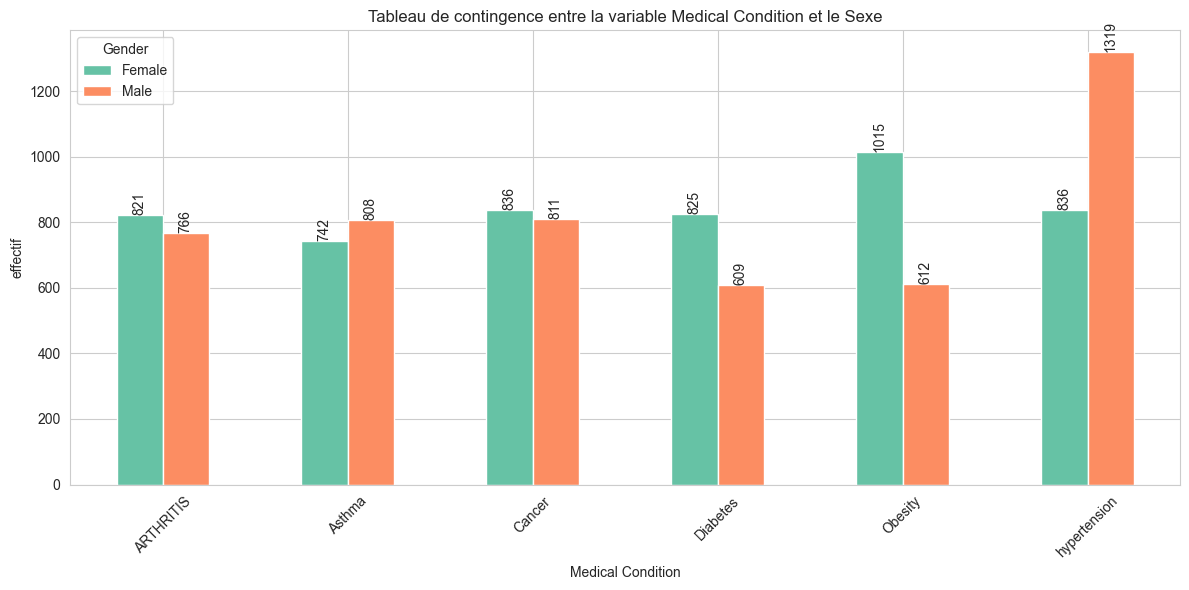

In [68]:
fig, ax= plt.subplots(figsize=(12,6))
MedCon_vs_Gender.plot(kind ='bar',ax=ax)
ax.set_title('Tableau de contingence entre la variable Medical Condition et le Sexe')
ax.set_xlabel('Medical Condition')
ax.set_ylabel('effectif')
ax.tick_params(axis='x',rotation=45)
plt.tight_layout()

# pour ajouter les etiquettes verticales sur les barres
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),str(p.get_height()),ha='center',va='bottom',rotation=90)
plt.show()

In [69]:
data.columns

Index(['Name', 'Age', 'Age check', 'Age Group', 'Gender', 'Trimmed Gender',
       'Demographic Group', 'Blood Type', 'Medical Condition',
       'Updated Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Billing Check', 'Room Number', 'Admission Type',
       'Trimmed Ad Type', 'Updated Admission Type', 'Updated Discharge Date',
       'Medication', 'Test Results', 'Days of admission'],
      dtype='object')

In [70]:
# création d'une table croisée entre 'Blood Type' et 'Medical Condition'
BlTp_vs_MeCon = pd.crosstab(data['Blood Type'],data['Medical Condition'])
BlTp_vs_MeCon

Medical Condition,ARTHRITIS,Asthma,Cancer,Diabetes,Obesity,hypertension
Blood Type,,,,,,
A+,194,210,201,171,200,265
A-,190,199,202,186,201,260
AB+,219,178,200,182,211,268
AB-,194,184,189,192,239,277
B+,197,191,215,177,182,282
B-,181,194,215,197,206,259
O+,203,210,218,155,194,268
O-,209,184,207,174,194,276


<function matplotlib.pyplot.show(close=None, block=None)>

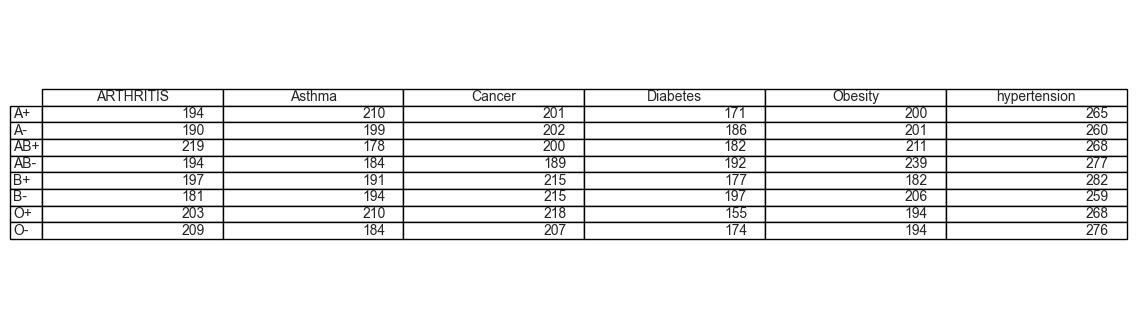

In [71]:
fig,ax = plt.subplots(figsize=(14,4))
ax.axis('off') # pour masquer les axes
ax.table(cellText=BlTp_vs_MeCon.values,rowLabels=BlTp_vs_MeCon.index,colLabels=BlTp_vs_MeCon.columns,loc='center')
plt.show

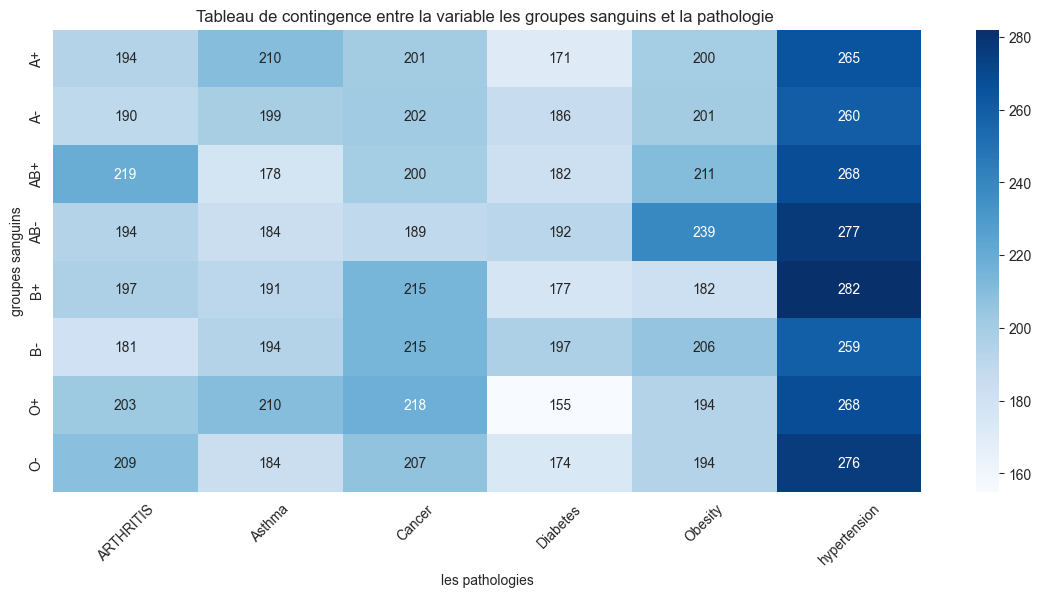

In [72]:
plt.figure(figsize=(14,6))
ax=sns.heatmap(BlTp_vs_MeCon,annot=True,cmap='Blues',fmt='d')
plt.title('Tableau de contingence entre la variable les groupes sanguins et la pathologie ')
ax.set_xlabel('les pathologies')
ax.set_ylabel('groupes sanguins')
ax.tick_params(axis='x',rotation=45)
plt.show()

In [73]:
# création d'une table croisée entre 'Insurance Provider' et 'Medical Condition'
medCon_vs_ins = pd.crosstab(data['Insurance Provider'],data['Medical Condition'])
medCon_vs_ins

Medical Condition,ARTHRITIS,Asthma,Cancer,Diabetes,Obesity,hypertension
Insurance Provider,,,,,,
Aetna,270,330,332,263,309,417
Blue Cross,289,318,272,269,348,379
Cigna,289,338,315,272,300,425
Medicare,455,280,426,359,375,533
UnitedHealthcare,284,284,302,271,295,401


<function matplotlib.pyplot.show(close=None, block=None)>

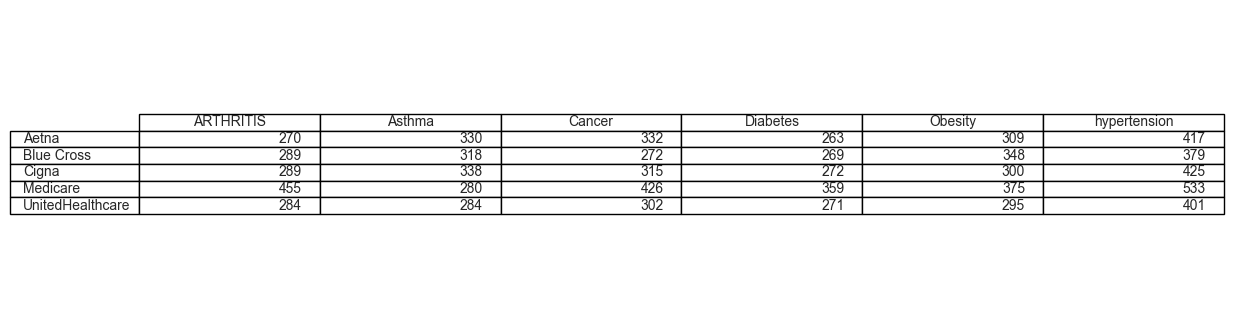

In [74]:
fig,ax = plt.subplots(figsize=(14,4))
ax.axis('off') # pour masquer les axes
ax.table(cellText=medCon_vs_ins.values,rowLabels=medCon_vs_ins.index,colLabels=medCon_vs_ins.columns,loc='center')
plt.show

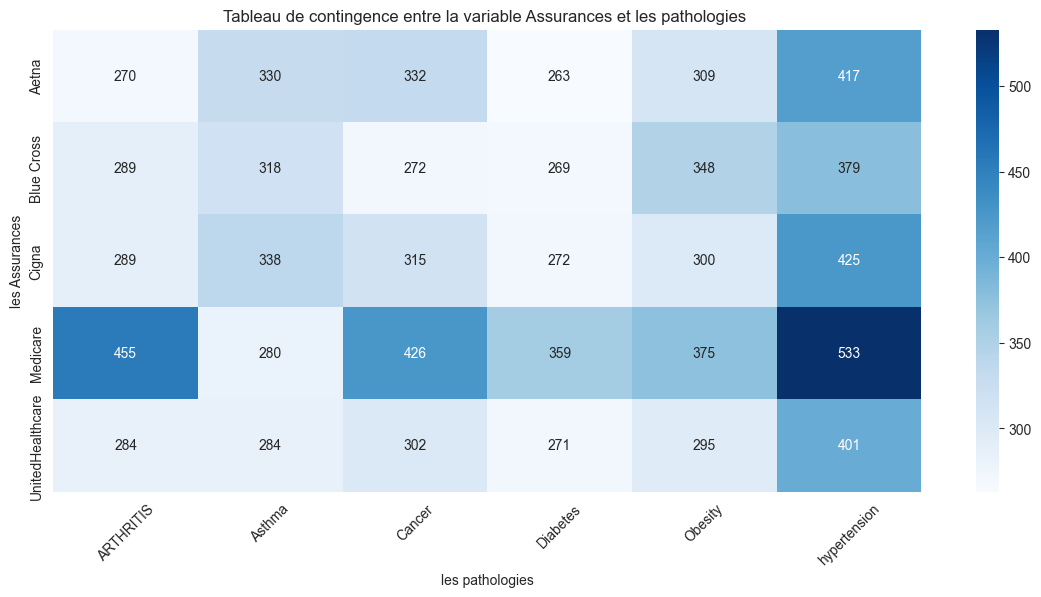

In [75]:
plt.figure(figsize=(14,6))
ax=sns.heatmap(medCon_vs_ins,annot=True,cmap='Blues',fmt='d')
plt.title('Tableau de contingence entre la variable Assurances et les pathologies ')
ax.set_xlabel('les pathologies')
ax.set_ylabel('les Assurances')
ax.tick_params(axis='x',rotation=45)
plt.show()

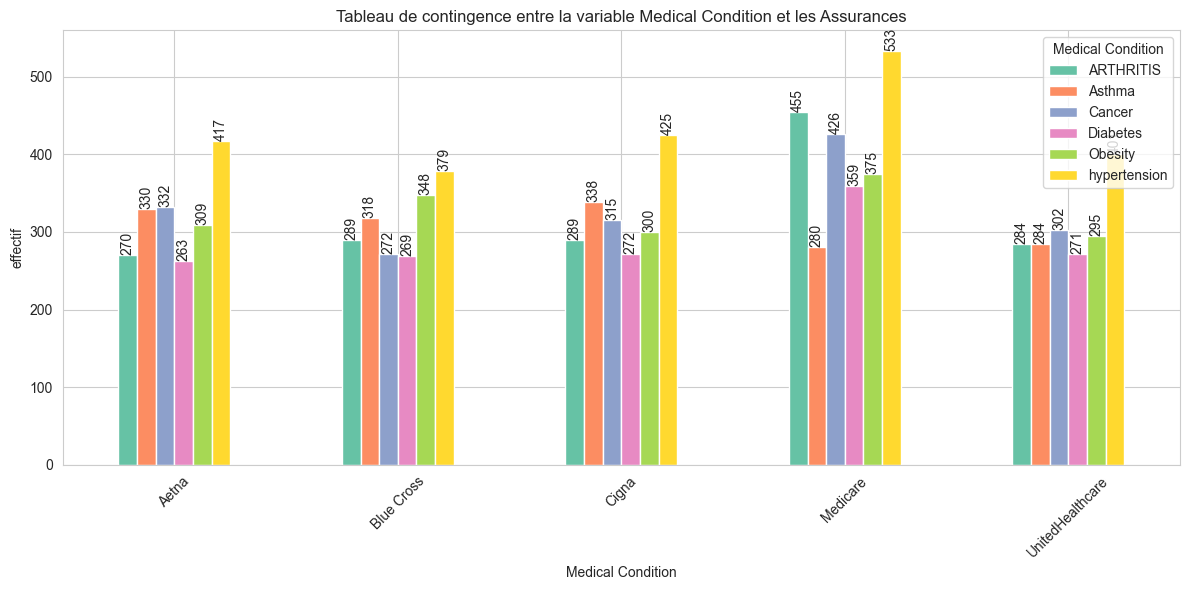

In [76]:
fig, ax= plt.subplots(figsize=(12,6))
medCon_vs_ins.plot(kind ='bar', ax=ax)
ax.set_title('Tableau de contingence entre la variable Medical Condition et les Assurances')
ax.set_xlabel('Medical Condition')
ax.set_ylabel('effectif')
ax.tick_params(axis='x',rotation=45)
plt.tight_layout()

# pour ajouter les etiquettes verticales sur les barres
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),str(p.get_height()),ha='center',va='bottom',rotation=90)
plt.show()

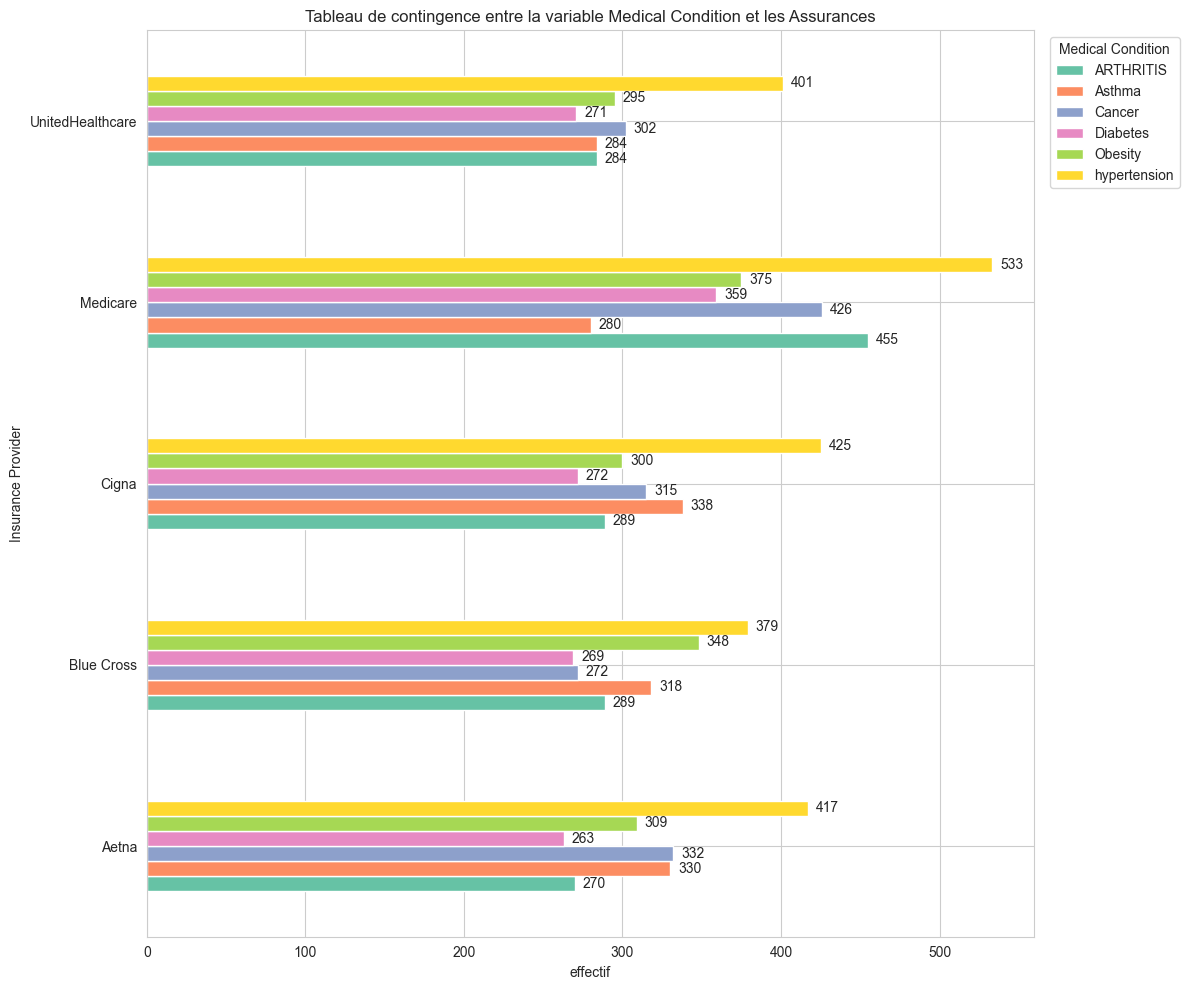

In [77]:
fig, ax = plt.subplots(figsize=(12,10))
medCon_vs_ins.plot(kind='barh', stacked=False, ax=ax)
ax.set_title('Tableau de contingence entre la variable Medical Condition et les Assurances')
ax.set_xlabel('effectif')
ax.set_ylabel('Insurance Provider')
ax.legend(title='Medical Condition', bbox_to_anchor=(1.01, 1), loc='upper left')

for p in ax.patches:
    width = p.get_width()
    ax.text(width + max(5, width*0.01), p.get_y() + p.get_height()/2, str(int(width)), va='center')

plt.tight_layout()
plt.show()

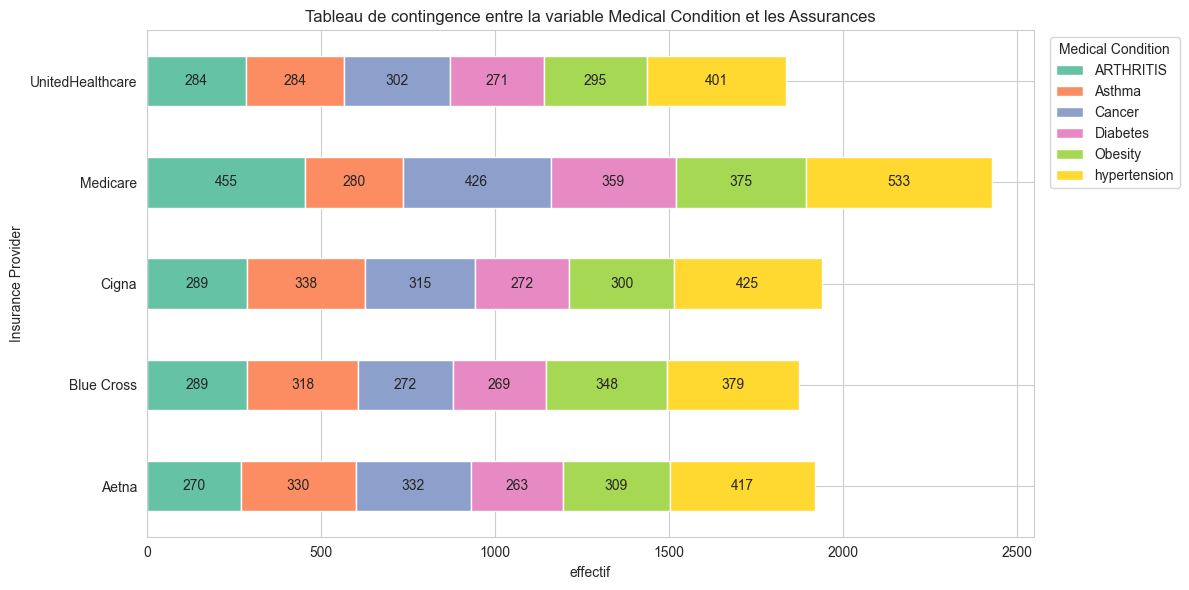

In [78]:
fig, ax = plt.subplots(figsize=(12,6))
medCon_vs_ins.plot(kind='barh', stacked=True, ax=ax)
ax.set_title('Tableau de contingence entre la variable Medical Condition et les Assurances')
ax.set_xlabel('effectif')
ax.set_ylabel('Insurance Provider')
ax.legend(title='Medical Condition', bbox_to_anchor=(1.01, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='center')

plt.tight_layout()
plt.show()

In [79]:
data.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['Name', 'Age', 'Age check', 'Age Group', 'Gender', 'Trimmed Gender',
       'Demographic Group', 'Blood Type', 'Medical Condition',
       'Updated Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Billing Check', 'Room Number', 'Admission Type',
       'Trimmed Ad Type', 'Updated Admission Type', 'Updated Discharge Date',
       'Medication', 'Test Results', 'Days of admission'],
      dtype='object')>

In [80]:
# création d'une table croisée entre 'Medical Condition' et 'Admission Type'
AdTy_vs_MeCon = pd.crosstab(data['Medical Condition'],data['Admission Type'])
AdTy_vs_MeCon

Admission Type,Elective,Emergency,Urgent
Medical Condition,,,
ARTHRITIS,867,297,423
Asthma,213,517,820
Cancer,689,750,208
Diabetes,126,653,655
Obesity,925,377,325
hypertension,257,993,905


<function matplotlib.pyplot.show(close=None, block=None)>

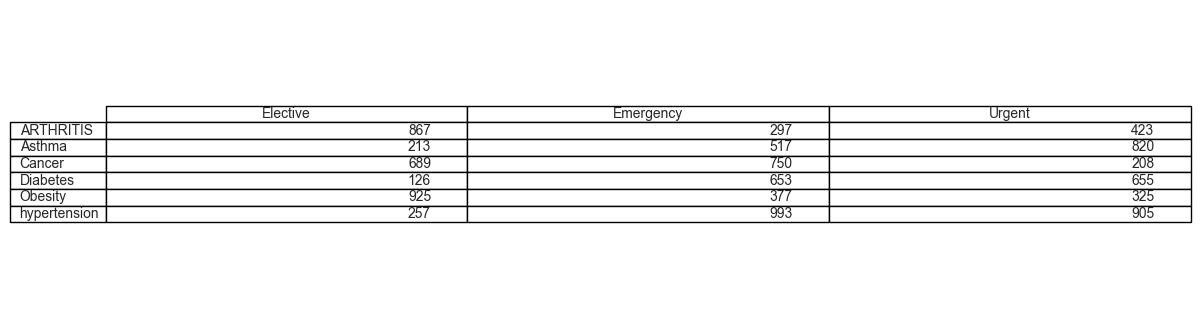

In [81]:
fig,ax = plt.subplots(figsize=(14,4))
ax.axis('off') # pour masquer les axes
ax.table(cellText=AdTy_vs_MeCon.values,rowLabels=AdTy_vs_MeCon.index,colLabels=AdTy_vs_MeCon.columns,loc='center')
plt.show

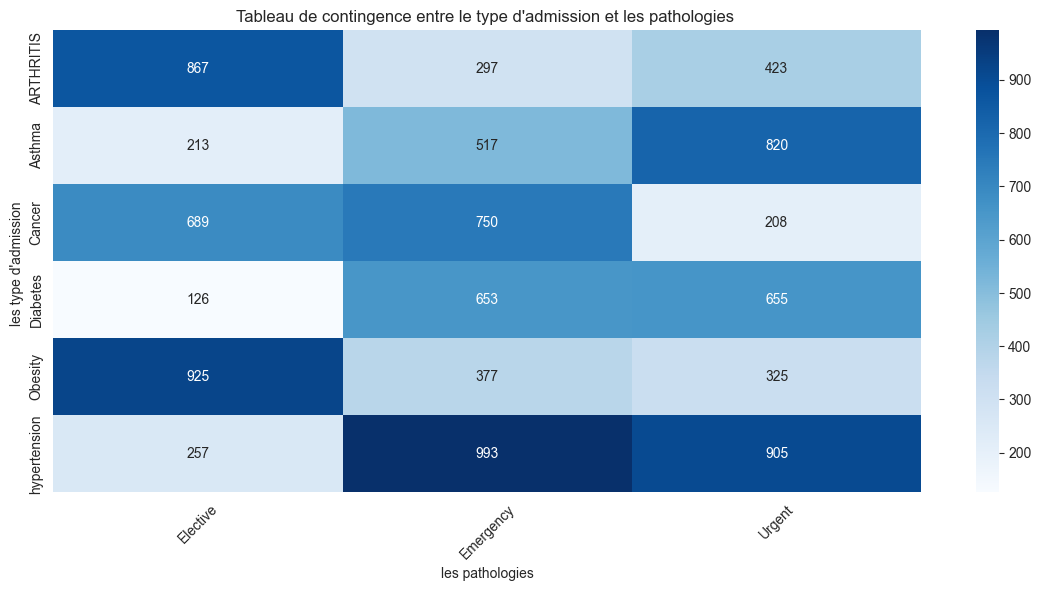

In [82]:
plt.figure(figsize=(14,6))
ax=sns.heatmap(AdTy_vs_MeCon,annot=True,cmap='Blues',fmt='d')
plt.title("Tableau de contingence entre le type d'admission et les pathologies ")
ax.set_xlabel('les pathologies')
ax.set_ylabel("les type d'admission ")
ax.tick_params(axis='x',rotation=45)
plt.show()

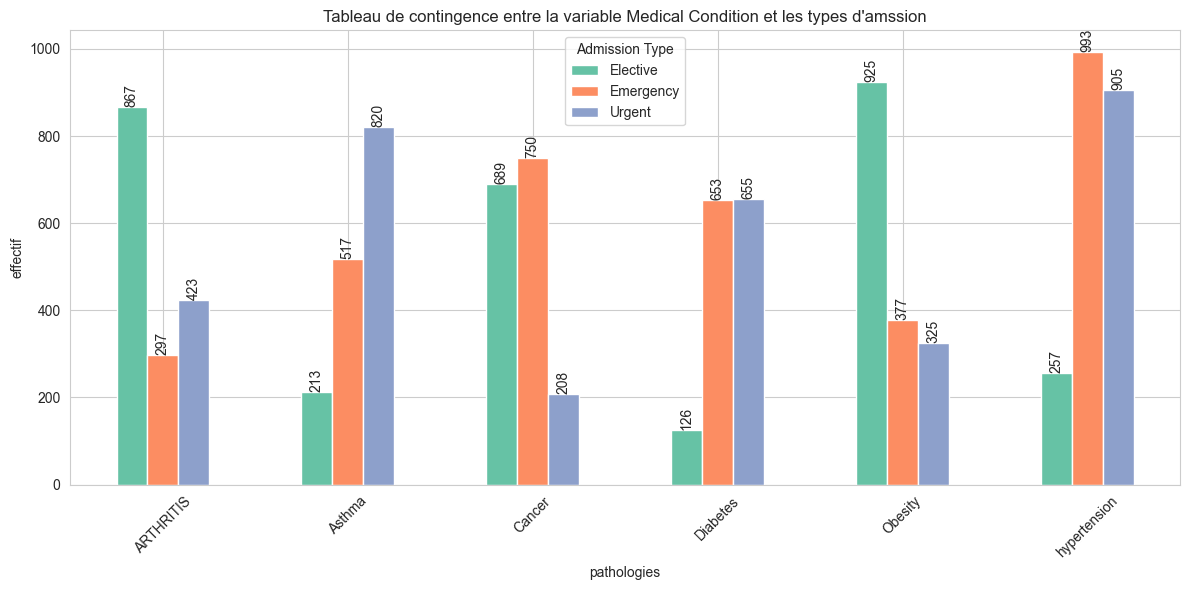

In [83]:
fig, ax= plt.subplots(figsize=(12,6))
AdTy_vs_MeCon.plot(kind ='bar',ax=ax)
ax.set_title("Tableau de contingence entre la variable Medical Condition et les types d'amssion")
ax.set_xlabel('pathologies')
ax.set_ylabel('effectif')
ax.tick_params(axis='x',rotation=45)
plt.tight_layout()

# pour ajouter les etiquettes verticales sur les barres
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height(),str(p.get_height()),ha='center',va='bottom',rotation=90)
plt.show()

#### les prix Total et Moyens pour chaque pathologie

In [84]:
# calcul du prix total par pathologie
prix__par_pathologie = data.groupby('Medical Condition')['Billing Amount'].sum().reset_index().sort_values(by='Billing Amount', ascending=True)
prix__par_pathologie

,Medical Condition,Billing Amount
4,Obesity,2.031581e+07
0,ARTHRITIS,3.173342e+07
1,Asthma,3.503612e+07
5,hypertension,3.788240e+07
3,Diabetes,4.298115e+07
2,Cancer,6.520237e+07


C:\Users\user\AppData\Local\Temp\ipykernel_4432\3499664899.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(x='Medical Condition', y='Billing Amount', data =prix__par_pathologie,palette='hsv')


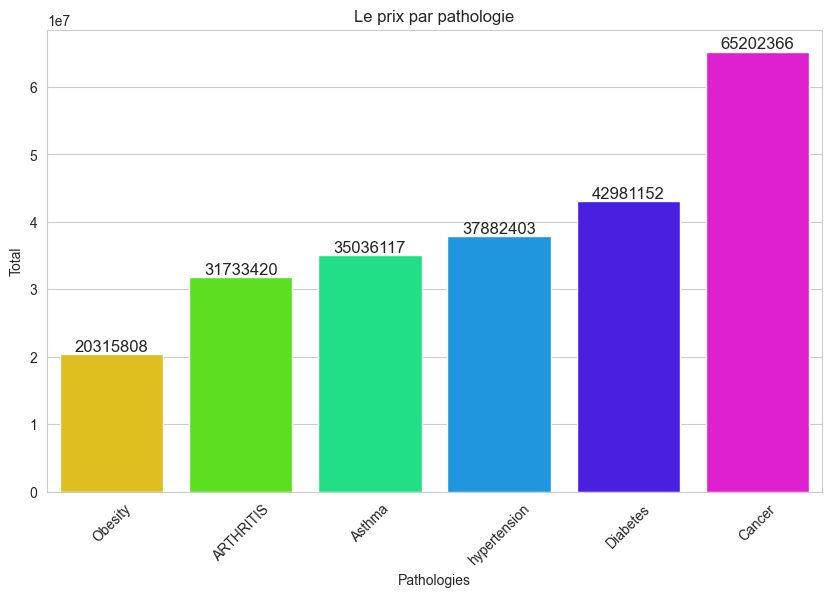

In [85]:
plt.figure(figsize = (10,6))
ax= sns.barplot(x='Medical Condition', y='Billing Amount', data =prix__par_pathologie,palette='hsv')
plt.title('Le prix par pathologie')
plt.xlabel('Pathologies')
plt.ylabel('Total')
plt.xticks(rotation=45)


for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 12)
    
plt.show()

In [91]:
prix_moyen_par_pathologie = data.groupby('Medical Condition')['Billing Amount'].mean().reset_index().sort_values(by='Billing Amount', ascending=True)
prix_moyen_par_pathologie['Billing Amount'] = prix_moyen_par_pathologie['Billing Amount'].round(2)
prix_moyen_par_pathologie

,Medical Condition,Billing Amount
4,Obesity,12486.67
5,hypertension,17578.84
0,ARTHRITIS,19995.85
1,Asthma,22603.95
3,Diabetes,29972.91
2,Cancer,39588.57


C:\Users\user\AppData\Local\Temp\ipykernel_4432\866297033.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(x='Medical Condition', y='Billing Amount', data =prix_moyen_par_pathologie,palette='Set2')


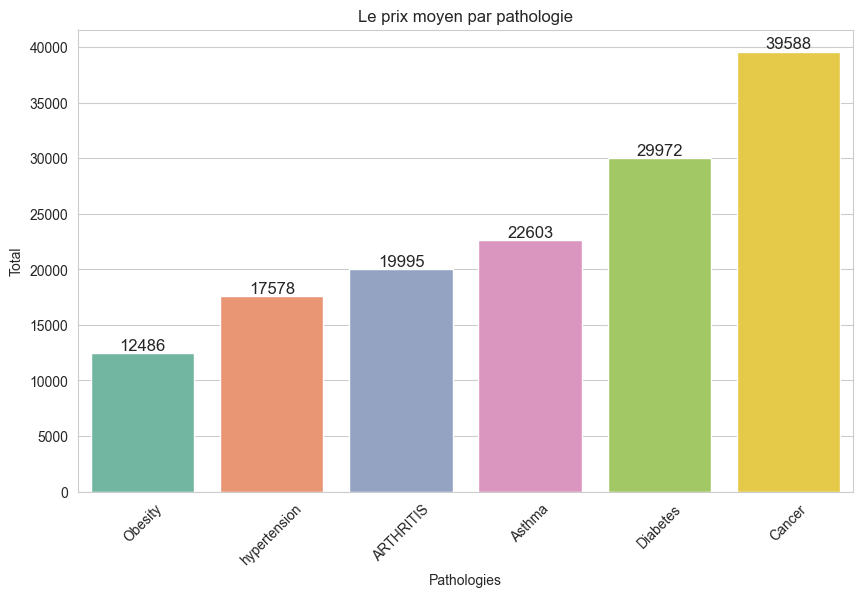

In [92]:
plt.figure(figsize = (10,6))
ax= sns.barplot(x='Medical Condition', y='Billing Amount', data =prix_moyen_par_pathologie,palette='Set2')
plt.title('Le prix moyen par pathologie')
plt.xlabel('Pathologies')
plt.ylabel('Total')
plt.xticks(rotation=45)


for p in ax.patches :
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 10 ,str(int(p.get_height())),
                ha = 'center', va='bottom', fontsize= 12)
    
plt.show()

In [88]:
data.columns

Index(['Name', 'Age', 'Age check', 'Age Group', 'Gender', 'Trimmed Gender',
       'Demographic Group', 'Blood Type', 'Medical Condition',
       'Updated Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Billing Check', 'Room Number', 'Admission Type',
       'Trimmed Ad Type', 'Updated Admission Type', 'Updated Discharge Date',
       'Medication', 'Test Results', 'Days of admission'],
      dtype='object')

In [89]:
# conversion de la colonne de date en datetime
data['Updated Date of Admission']=pd.to_datetime(data['Updated Date of Admission'])
data['Updated Discharge Date']=pd.to_datetime(data['Updated Discharge Date'])

# Definir la colonne date comme index
# data.set_index('Updated Date of Admission',inplace=True)

In [90]:
# plt.figure(figsize = (10,6))
# sns.lineplot(x='Updated Date of Admission',y='Days of admission',data=data)
# plt.title('Serie temporelle du montant des soins')
# plt.xlabel('Date')
# plt.ylabel('Nombre de jours d admission')
# plt.grid(True)
# plt.show()